# Analisis 2 - Correlacion con rezagos y causalidad de Granger

**Objetivo:** Cuantificar la asociacion entre tasa de homicidios y llegadas internacionales a Ecuador (2010-2024), identificar el rezago optimo (0-3 anos) y testear causalidad de Granger.

**Hipotesis H2:** Correlacion negativa significativa entre tasa de homicidios y llegadas turisticas con rezago de 6-18 meses; mercados emisores lejanos (Europa, Norteamerica) mas sensibles que regionales (Colombia, Peru).

**Criterios de exito:** p<0.05 en Granger en al menos un lag; |r|>0.6 en correlacion global con lag optimo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Librerias cargadas')

Librerias cargadas


## 1. Llegadas anuales BM (2010-2022)

In [2]:
with zipfile.ZipFile('../data/raw/banco_mundial/API_ST.INT.ARVL_DS2_es_csv_v2_4967.zip') as z:
    fn = [n for n in z.namelist() if n.endswith('.csv') and 'Metadata' not in n][0]
    with z.open(fn) as f:
        raw_bm = pd.read_csv(f, skiprows=4, encoding='utf-8')

ecu_bm = raw_bm[raw_bm['Country Code'] == 'ECU'].copy()
years_all = [str(y) for y in range(2010, 2025)]
bm_long = (
    ecu_bm[['Country Name'] + years_all]
    .melt(id_vars='Country Name', var_name='anio', value_name='llegadas')
)
bm_long['anio'] = bm_long['anio'].astype(int)
bm_long = bm_long.dropna(subset=['llegadas'])
bm_long['llegadas'] = bm_long['llegadas'].astype(int)
print('BM llegadas Ecuador:')
print(bm_long[['anio','llegadas']].to_string(index=False))

BM llegadas Ecuador:
 anio  llegadas
 2010   1047000
 2011   1141000
 2012   1272000
 2013   1364000
 2014   1695000
 2015   1676000
 2016   1569000
 2017   1806000
 2018   2535000
 2019   2108000


## 2. Llegadas ESI 2023-2024 (extranjeros, motivo Turismo) por nacionalidad

In [3]:
import duckdb
con = duckdb.connect()
# Nota: el archivo esi2023.csv esta fisicamente ubicado en la carpeta "Datos_abiertos_ ESI_2015"
# (carpeta mal nombrada en la descarga original). Se usa esa ruta tal cual.
ESI_2023 = '../data/raw/entradas_salidas/Datos_abiertos_ ESI_2015/esi2023.csv'
ESI_2024 = '../data/raw/entradas_salidas/Datos_abiertos_ ESI_2024/esi_2024.csv'

# Detectar columnas disponibles primero
cols_2023 = con.execute(f"SELECT * FROM read_csv_auto('{ESI_2023}') LIMIT 0").df().columns.tolist()
print('Columnas ESI 2023:', cols_2023)

# Para nacionalidad del viajero usamos nac_migr (codigo/pais de nacionalidad del migrante)
col_nac = 'nac_migr' if 'nac_migr' in cols_2023 else None
if col_nac is None:
    # fallback
    for cand in ['pais_res','jefatura_nacionalidad','nacionalidad']:
        if cand in cols_2023:
            col_nac = cand; break
print('Columna de nacionalidad utilizada:', col_nac)

Columnas ESI 2023: ['secuencial', 'tip_movi', 'tip_naci', 'anio_movi', 'mes_movi', 'dia_movi', 'sex_migr', 'nac_migr', 'subcont_nac', 'cont_nac', 'via_tran', 'mot_viam', 'pais_prod', 'subcont_prod', 'cont_prod', 'lug_prod', 'pais_res', 'subcont_res', 'cont_res', 'jef_migr', 'pro_jefm', 'can_jefm', 'cla_migr', 'ocu_migr', 'edad']
Columna de nacionalidad utilizada: nac_migr


In [4]:
df_esi = con.execute(f"""
    SELECT anio_movi AS anio, {col_nac} AS nacionalidad,
           COUNT(*) AS total
    FROM (
        SELECT anio_movi, tip_movi, tip_naci, mot_viam, {col_nac} FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT anio_movi, tip_movi, tip_naci, mot_viam, {col_nac} FROM read_csv_auto('{ESI_2024}')
    )
    WHERE tip_movi='Entrada' AND tip_naci='Extranjero' AND mot_viam='Turismo'
    GROUP BY anio_movi, {col_nac}
""").df()

esi_anual = df_esi.groupby('anio')['total'].sum().reset_index().rename(columns={'total':'llegadas'})
print('ESI turismo extranjeros anual:')
print(esi_anual.to_string(index=False))
print()
print('Top nacionalidades agregadas 2023-2024:')
print(df_esi.groupby('nacionalidad')['total'].sum().sort_values(ascending=False).head(15))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ESI turismo extranjeros anual:
 anio  llegadas
 2023    863161
 2024    703110

Top nacionalidades agregadas 2023-2024:
nacionalidad
Estados Unidos de América    493590
Colombia                     331113
Perú                         141589
España                        75838
China                         55724
Canadá                        45762
Alemania                      42355
Reino Unido                   39063
México                        29129
Francia                       28636
Chile                         26850
Argentina                     26456
Brasil                        19856
Italia                        18061
Países Bajos                  15460
Name: total, dtype: int64


## 3. Serie unificada de llegadas 2010-2024

BM cubre 2010-2019 (no reporta 2020-2024 en este dataset). Para 2023-2024 usamos ESI (entradas de extranjeros con motivo Turismo). El gap 2020-2022 queda sin datos para llegadas.

In [5]:
serie_bm = bm_long[['anio','llegadas']].copy()
serie_bm['fuente'] = 'BM'
serie_esi = esi_anual.copy()
serie_esi['fuente'] = 'ESI'
llegadas = pd.concat([serie_bm, serie_esi], ignore_index=True).sort_values('anio').reset_index(drop=True)
print('Serie unificada de llegadas:')
print(llegadas.to_string(index=False))
anios_disponibles = sorted(llegadas['anio'].unique())
print(f'\nGap (sin datos): {sorted(set(range(2010,2025)) - set(anios_disponibles))}')

Serie unificada de llegadas:
 anio  llegadas fuente
 2010   1047000     BM
 2011   1141000     BM
 2012   1272000     BM
 2013   1364000     BM
 2014   1695000     BM
 2015   1676000     BM
 2016   1569000     BM
 2017   1806000     BM
 2018   2535000     BM
 2019   2108000     BM
 2023    863161    ESI
 2024    703110    ESI

Gap (sin datos): [2020, 2021, 2022]


## 4. Serie de tasa de homicidios 2010-2024

Fuente principal: Banco Mundial/UNODC (tasa por 100.000 hab.). Para anios mas recientes (no cubiertos por BM) complementamos con conteos MDI convertidos a tasa usando poblacion INEC.

In [6]:
df_tasa = pd.read_csv('../data/raw/seguridad/API_VC.IHR.PSRC.P5_DS2_es_csv_v2_8348.csv', skiprows=4)
ecu_tasa = df_tasa[df_tasa['Country Code']=='ECU']
tasa_long = (
    ecu_tasa[['Country Name'] + years_all]
    .melt(id_vars='Country Name', var_name='anio', value_name='tasa_hom')
    .dropna(subset=['tasa_hom'])
)
tasa_long['anio'] = tasa_long['anio'].astype(int)
print('Tasa homicidios BM/UNODC Ecuador:')
print(tasa_long[['anio','tasa_hom']].to_string(index=False))

Tasa homicidios BM/UNODC Ecuador:
 anio  tasa_hom
 2010 17.404345
 2011 15.287520
 2012 12.342513
 2013 10.912799
 2014  8.169566
 2015  6.455093
 2016  5.810312
 2017  5.787755
 2018  5.830067
 2019  6.845436
 2020  7.819417
 2021 14.115687
 2022 27.412636
 2023 45.722815


In [7]:
# Conteo MDI a partir del archivo "pm" (registros individuales con fecha_infraccion)
df_mdi = pd.read_excel(
    '../data/raw/seguridad/mdi_homicidiosintencionales_pm_2014_2025.xlsx',
    sheet_name='1. Homicidios Intencionales'
)
print('Cols MDI pm:', list(df_mdi.columns)[:5], '...')

df_mdi['fecha'] = pd.to_datetime(df_mdi['fecha_infraccion'], errors='coerce')
df_mdi['anio'] = df_mdi['fecha'].dt.year
mdi_anual = df_mdi.dropna(subset=['anio']).groupby('anio').size().reset_index(name='hom_count')
mdi_anual['anio'] = mdi_anual['anio'].astype(int)
mdi_anual = mdi_anual[mdi_anual['anio'].between(2014, 2024)]

# Poblacion media Ecuador (en millones) - INEC/BM
pop_ecu = {
    2010: 15.012, 2011: 15.266, 2012: 15.520, 2013: 15.775, 2014: 16.027,
    2015: 16.279, 2016: 16.530, 2017: 16.785, 2018: 17.042, 2019: 17.301,
    2020: 17.589, 2021: 17.798, 2022: 17.997, 2023: 18.190, 2024: 18.349
}
# tasa = homicidios / (millones de hab * 10) = por 100k hab
mdi_anual['tasa_mdi'] = mdi_anual.apply(lambda r: r['hom_count']/(pop_ecu[r['anio']]*10), axis=1)
print('\nMDI agregado anual con tasa estimada:')
print(mdi_anual.to_string(index=False))

Cols MDI pm: ['tipo_muerte', 'zona', 'subzona', 'distrito', 'circuito'] ...

MDI agregado anual con tasa estimada:
 anio  hom_count  tasa_mdi
 2014       1310  8.173707
 2015       1050  6.450028
 2016        959  5.801573
 2017        970  5.778969
 2018        996  5.844384
 2019       1189  6.872435
 2020       1372  7.800330
 2021       2495 14.018429
 2022       4886 27.148969
 2023       8248 45.343595
 2024       7063 38.492561


In [8]:
tasa_unificada = tasa_long[['anio','tasa_hom']].copy()
anios_bm = set(tasa_unificada['anio'])
faltantes = [a for a in range(2010,2025) if a not in anios_bm]
print('Anios faltantes en tasa BM:', faltantes)
rellenos = mdi_anual[mdi_anual['anio'].isin(faltantes)][['anio','tasa_mdi']].rename(columns={'tasa_mdi':'tasa_hom'})
tasa_unificada = pd.concat([tasa_unificada, rellenos], ignore_index=True).sort_values('anio').reset_index(drop=True)
print('\nTasa unificada 2010-2024:')
print(tasa_unificada.to_string(index=False))

Anios faltantes en tasa BM: [2024]

Tasa unificada 2010-2024:
 anio  tasa_hom
 2010 17.404345
 2011 15.287520
 2012 12.342513
 2013 10.912799
 2014  8.169566
 2015  6.455093
 2016  5.810312
 2017  5.787755
 2018  5.830067
 2019  6.845436
 2020  7.819417
 2021 14.115687
 2022 27.412636
 2023 45.722815
 2024 38.492561


## 5. Correlaciones con lag 0-3 anos

Hipotesis H2: la tasa de homicidios del anio t-k impacta las llegadas en el anio t (k=0,1,2,3).

In [9]:
df = llegadas[['anio','llegadas']].merge(tasa_unificada, on='anio', how='outer').sort_values('anio').reset_index(drop=True)
print('DataFrame combinado:')
print(df.to_string(index=False))

DataFrame combinado:
 anio  llegadas  tasa_hom
 2010 1047000.0 17.404345
 2011 1141000.0 15.287520
 2012 1272000.0 12.342513
 2013 1364000.0 10.912799
 2014 1695000.0  8.169566
 2015 1676000.0  6.455093
 2016 1569000.0  5.810312
 2017 1806000.0  5.787755
 2018 2535000.0  5.830067
 2019 2108000.0  6.845436
 2020       NaN  7.819417
 2021       NaN 14.115687
 2022       NaN 27.412636
 2023  863161.0 45.722815
 2024  703110.0 38.492561


In [10]:
def get_tasa(a):
    s = df.loc[df['anio']==a, 'tasa_hom']
    if len(s)==0 or s.isna().all():
        return np.nan
    return float(s.values[0])

resultados_lag = []
for k in range(0, 4):
    sub = df.dropna(subset=['llegadas']).copy()
    sub['tasa_lag'] = sub['anio'].apply(lambda a: get_tasa(a - k))
    sub = sub.dropna(subset=['llegadas','tasa_lag'])
    if len(sub) < 4:
        resultados_lag.append({'lag': k, 'n': len(sub), 'pearson_r': np.nan, 'pearson_p': np.nan,
                                'spearman_r': np.nan, 'spearman_p': np.nan})
        continue
    pr, pp = stats.pearsonr(sub['tasa_lag'], sub['llegadas'])
    sr, sp = stats.spearmanr(sub['tasa_lag'], sub['llegadas'])
    resultados_lag.append({'lag': k, 'n': len(sub),
                            'pearson_r': pr, 'pearson_p': pp,
                            'spearman_r': sr, 'spearman_p': sp})

tabla_lag = pd.DataFrame(resultados_lag)
print('Correlacion por lag (homicidios -> llegadas):')
print(tabla_lag.round(4).to_string(index=False))
tabla_lag.to_csv('../outputs/tabla_correlacion_lag.csv', index=False)
print('\nGuardado: outputs/tabla_correlacion_lag.csv')

valid = tabla_lag.dropna(subset=['pearson_r'])
lag_opt = valid.iloc[valid['pearson_r'].abs().argmax()]
print(f'\nLag optimo (|Pearson| max): lag={int(lag_opt["lag"])}, r={lag_opt["pearson_r"]:.4f}, p={lag_opt["pearson_p"]:.4f}, n={int(lag_opt["n"])}')

Correlacion por lag (homicidios -> llegadas):
 lag  n  pearson_r  pearson_p  spearman_r  spearman_p
   0 12    -0.7631     0.0039     -0.8601      0.0003
   1 11    -0.8176     0.0021     -0.9545      0.0000
   2 10    -0.8438     0.0021     -0.9030      0.0003
   3  9    -0.4743     0.1971     -0.5500      0.1250

Guardado: outputs/tabla_correlacion_lag.csv

Lag optimo (|Pearson| max): lag=2, r=-0.8438, p=0.0021, n=10


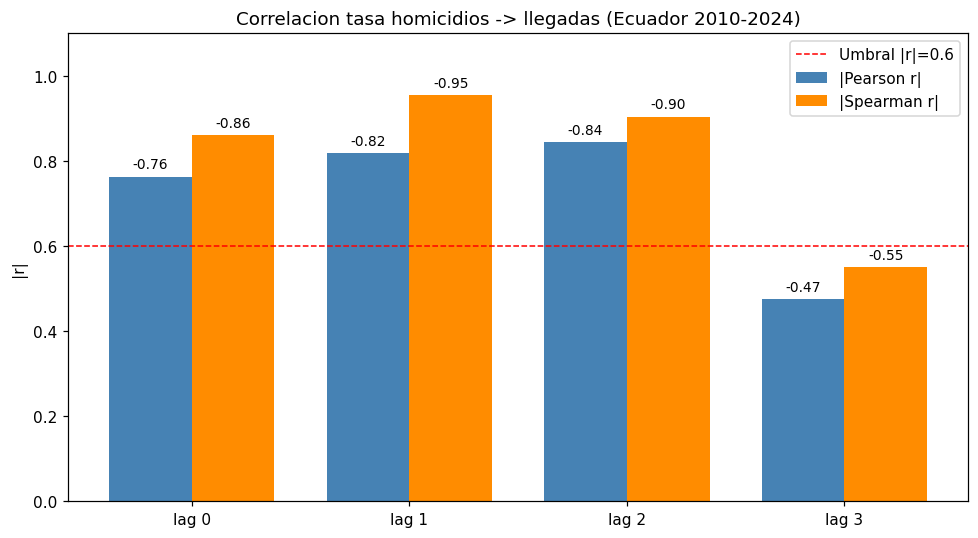

Guardado: outputs/06_correlacion_lag.png


In [11]:
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(tabla_lag))
w = 0.38
ax.bar(x - w/2, tabla_lag['pearson_r'].abs(), w, label='|Pearson r|', color='steelblue')
ax.bar(x + w/2, tabla_lag['spearman_r'].abs(), w, label='|Spearman r|', color='darkorange')
for i, row in tabla_lag.iterrows():
    if not np.isnan(row['pearson_r']):
        ax.text(i-w/2, abs(row['pearson_r'])+0.02, f"{row['pearson_r']:+.2f}", ha='center', fontsize=9)
    if not np.isnan(row['spearman_r']):
        ax.text(i+w/2, abs(row['spearman_r'])+0.02, f"{row['spearman_r']:+.2f}", ha='center', fontsize=9)
ax.axhline(0.6, color='red', linestyle='--', linewidth=1, label='Umbral |r|=0.6')
ax.set_xticks(x); ax.set_xticklabels([f'lag {l}' for l in tabla_lag['lag']])
ax.set_ylabel('|r|'); ax.set_ylim(0, 1.1)
ax.set_title('Correlacion tasa homicidios -> llegadas (Ecuador 2010-2024)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/06_correlacion_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/06_correlacion_lag.png')

## 6. Test de causalidad de Granger

Granger requiere serie continua. Usamos el tramo 2010-2019 (BM tiene todos los anios). Por la corta serie interpretamos con cautela.

In [12]:
serie_granger = df.dropna(subset=['llegadas','tasa_hom']).copy()
serie_granger = serie_granger[serie_granger['anio'].between(2010, 2019)].sort_values('anio').reset_index(drop=True)
print('Serie continua para Granger:')
print(serie_granger.to_string(index=False))

# Adaptar maxlag al limite real que admite statsmodels para esta longitud.
# Con n observaciones, grangercausalitytests exige n - 3*lag - ... ; en la practica
# el maximo admisible aqui (n=10) es 2. Topamos en 2 para no exceder ese limite.
n_serie = len(serie_granger)
maxlag_real = min(2, max(1, (n_serie // 2) - 1))
print(f'\nMaxlag real para Granger (n={n_serie}): {maxlag_real}')

granger_pvalues = {}
try:
    arr = serie_granger[['llegadas','tasa_hom']].values
    res = grangercausalitytests(arr, maxlag=maxlag_real, verbose=False)
    for lag, r in res.items():
        granger_pvalues[lag] = r[0]['ssr_ftest'][1]
    print('\nP-valores Granger (homicidios -> llegadas):')
    for lag, p in granger_pvalues.items():
        marca = '** SIG **' if p < 0.05 else ''
        print(f'  lag {lag}: p = {p:.4f} {marca}')
    print('\nNota de potencia: con n=10 y lag 2 la regresion usa solo 8 obs. efectivas')
    print('(3 gl residuales). El resultado es indicativo, de baja potencia, no concluyente.')
except Exception as e:
    print('Error Granger:', e)
    granger_pvalues = {l: np.nan for l in range(1, maxlag_real+1)}

Serie continua para Granger:
 anio  llegadas  tasa_hom
 2010 1047000.0 17.404345
 2011 1141000.0 15.287520
 2012 1272000.0 12.342513
 2013 1364000.0 10.912799
 2014 1695000.0  8.169566
 2015 1676000.0  6.455093
 2016 1569000.0  5.810312
 2017 1806000.0  5.787755
 2018 2535000.0  5.830067
 2019 2108000.0  6.845436

Maxlag real para Granger (n=10): 2

P-valores Granger (homicidios -> llegadas):
  lag 1: p = 0.1766 
  lag 2: p = 0.0117 ** SIG **

Nota de potencia: con n=10 y lag 2 la regresion usa solo 8 obs. efectivas
(3 gl residuales). El resultado es indicativo, de baja potencia, no concluyente.


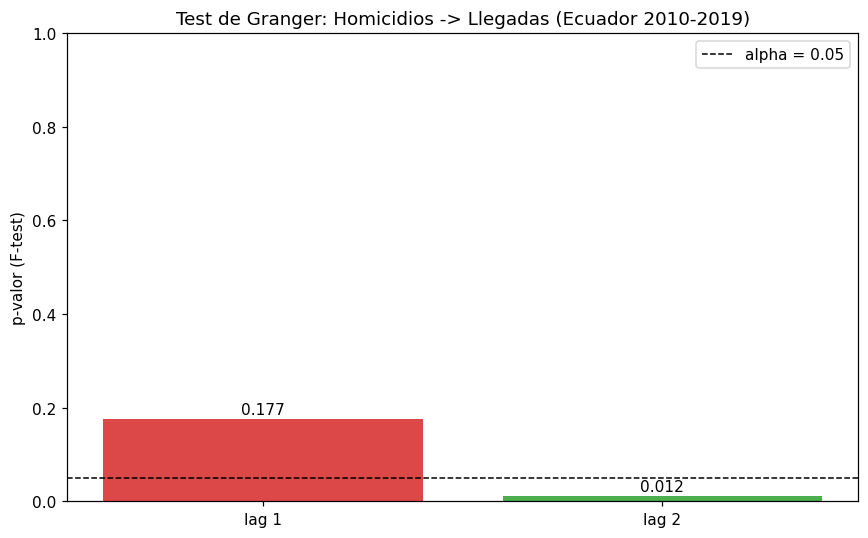

Guardado: outputs/07_granger_pvalues.png


In [13]:
fig, ax = plt.subplots(figsize=(8,5))
lags = list(granger_pvalues.keys())
pvals = [granger_pvalues[l] for l in lags]
colors = ['#2ca02c' if (p is not None and not np.isnan(p) and p<0.05) else '#d62728' for p in pvals]
bars = ax.bar([f'lag {l}' for l in lags], pvals, color=colors, alpha=0.85)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1, label='alpha = 0.05')
for b, p in zip(bars, pvals):
    if p is not None and not np.isnan(p):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{p:.3f}', ha='center', fontsize=10)
ax.set_ylabel('p-valor (F-test)')
ax.set_title('Test de Granger: Homicidios -> Llegadas (Ecuador 2010-2019)')
ax.legend()
valid_p = [p for p in pvals if p is not None and not np.isnan(p)]
ax.set_ylim(0, max(valid_p+[1]))
plt.tight_layout()
plt.savefig('../outputs/07_granger_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/07_granger_pvalues.png')

## 7. Sensibilidad por mercado emisor (top-5 ESI)

Para cada mercado: serie BM (estimada con cuota ESI 2023-2024 para 2010-2019) + ESI real 2023-2024. Correlacion con tasa de homicidios al lag optimo.

In [14]:
df_esi_nac = df_esi.groupby('nacionalidad')['total'].sum().sort_values(ascending=False).reset_index()
print('Top 10 mercados emisores ESI 2023-2024 (turismo):')
print(df_esi_nac.head(10).to_string(index=False))
top5 = df_esi_nac.head(5)['nacionalidad'].tolist()
print(f'\nTop-5 mercados: {top5}')

df_mkt = df_esi[df_esi['nacionalidad'].isin(top5)].groupby(['nacionalidad','anio'])['total'].sum().reset_index()
pivot_mkt = df_mkt.pivot(index='anio', columns='nacionalidad', values='total').reset_index()
print('\nLlegadas por mercado (ESI):')
print(pivot_mkt.to_string(index=False))

Top 10 mercados emisores ESI 2023-2024 (turismo):
             nacionalidad  total
Estados Unidos de América 493590
                 Colombia 331113
                     Perú 141589
                   España  75838
                    China  55724
                   Canadá  45762
                 Alemania  42355
              Reino Unido  39063
                   México  29129
                  Francia  28636

Top-5 mercados: ['Estados Unidos de América', 'Colombia', 'Perú', 'España', 'China']

Llegadas por mercado (ESI):
 anio  China  Colombia  España  Estados Unidos de América  Perú
 2023  38351    181657   40521                     262460 78023
 2024  17373    149456   35317                     231130 63566


In [15]:
lag_opt_k = int(lag_opt['lag'])
tasa_dict = dict(zip(tasa_unificada['anio'], tasa_unificada['tasa_hom']))
total_esi_2324 = df_esi['total'].sum()
share_mkt = {mkt: df_esi[df_esi['nacionalidad']==mkt]['total'].sum()/total_esi_2324 for mkt in top5}
print('Cuota de cada mercado en ESI 2023-2024:')
for m,s in share_mkt.items():
    print(f'  {m}: {s*100:.2f}%')

ranking = []
for mkt in top5:
    serie_mkt = []
    # Estimar llegadas historicas del mercado con cuota ESI aplicada a BM
    for _, row in bm_long.iterrows():
        serie_mkt.append({'anio': row['anio'], 'llegadas_mkt': row['llegadas']*share_mkt[mkt]})
    # Llegadas reales ESI 2023-2024
    for _, row in pivot_mkt.iterrows():
        if pd.notna(row[mkt]):
            serie_mkt.append({'anio': int(row['anio']), 'llegadas_mkt': float(row[mkt])})
    s_mkt = pd.DataFrame(serie_mkt).drop_duplicates(subset='anio').sort_values('anio')
    s_mkt['tasa_lag'] = s_mkt['anio'].apply(lambda a: tasa_dict.get(a - lag_opt_k, np.nan))
    s_mkt = s_mkt.dropna()
    if len(s_mkt) >= 4:
        r, p = stats.pearsonr(s_mkt['tasa_lag'], s_mkt['llegadas_mkt'])
        rs, ps = stats.spearmanr(s_mkt['tasa_lag'], s_mkt['llegadas_mkt'])
    else:
        r=p=rs=ps=np.nan
    ranking.append({'mercado': mkt, 'n': len(s_mkt),
                    'pearson_r': r, 'pearson_p': p,
                    'spearman_r': rs, 'spearman_p': ps,
                    'lag_usado': lag_opt_k})

tabla_sensibilidad = pd.DataFrame(ranking).sort_values('pearson_r')
print('\nRanking de sensibilidad por mercado (correlacion en lag optimo):')
print(tabla_sensibilidad.round(4).to_string(index=False))
tabla_sensibilidad.to_csv('../outputs/tabla_sensibilidad_mercados.csv', index=False)
print('\nGuardado: outputs/tabla_sensibilidad_mercados.csv')

Cuota de cada mercado en ESI 2023-2024:
  Estados Unidos de América: 31.51%
  Colombia: 21.14%
  Perú: 9.04%
  España: 4.84%
  China: 3.56%

Ranking de sensibilidad por mercado (correlacion en lag optimo):
                  mercado  n  pearson_r  pearson_p  spearman_r  spearman_p  lag_usado
                    China 10    -0.9037     0.0003      -0.903      0.0003          2
                     Perú 10    -0.8437     0.0022      -0.903      0.0003          2
                 Colombia 10    -0.8424     0.0022      -0.903      0.0003          2
                   España 10    -0.8342     0.0027      -0.903      0.0003          2
Estados Unidos de América 10    -0.8327     0.0028      -0.903      0.0003          2

Guardado: outputs/tabla_sensibilidad_mercados.csv


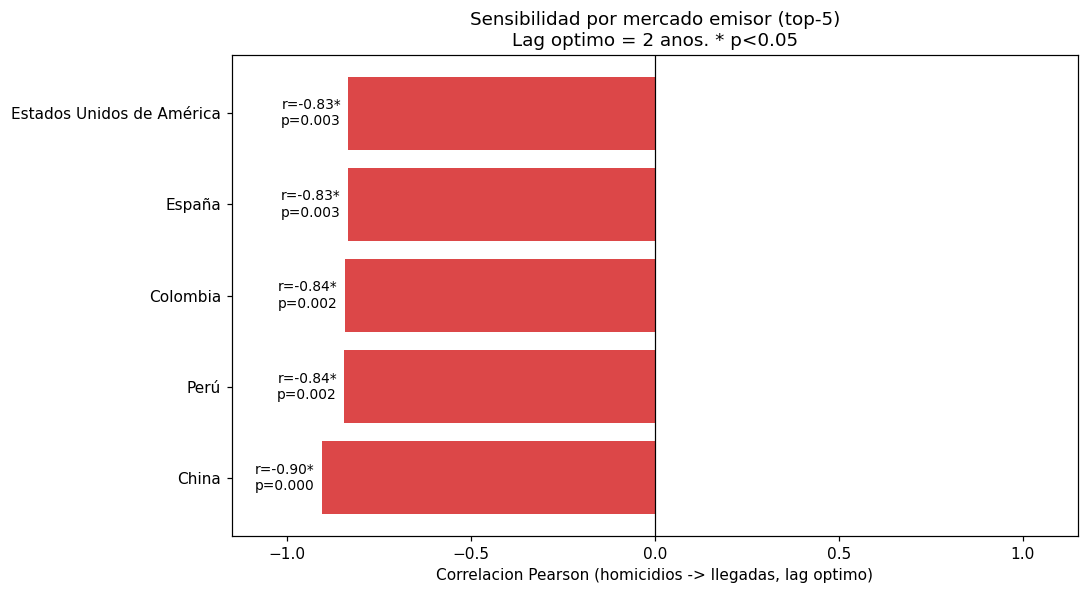

Guardado: outputs/08_sensibilidad_mercados.png


In [16]:
fig, ax = plt.subplots(figsize=(10,5.5))
tt = tabla_sensibilidad.dropna(subset=['pearson_r']).sort_values('pearson_r')
colors = ['#d62728' if r < 0 else '#2ca02c' for r in tt['pearson_r']]
bars = ax.barh(tt['mercado'], tt['pearson_r'], color=colors, alpha=0.85)
for b, r, p in zip(bars, tt['pearson_r'], tt['pearson_p']):
    marca = '*' if p < 0.05 else ''
    xt = b.get_width() + (0.02 if r>0 else -0.02)
    ha = 'left' if r>0 else 'right'
    ax.text(xt, b.get_y()+b.get_height()/2, f'r={r:+.2f}{marca}\np={p:.3f}', va='center', ha=ha, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion Pearson (homicidios -> llegadas, lag optimo)')
ax.set_title(f'Sensibilidad por mercado emisor (top-5)\nLag optimo = {lag_opt_k} anos. * p<0.05')
ax.set_xlim(-1.15, 1.15)
plt.tight_layout()
plt.savefig('../outputs/08_sensibilidad_mercados.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/08_sensibilidad_mercados.png')

## 8. Resumen ejecutivo

In [17]:
print('='*60)
print('RESUMEN - Analisis 2: Correlacion con lag y Granger')
print('='*60)
print(f'\nLag optimo: {int(lag_opt["lag"])} anos')
print(f'  Pearson r = {lag_opt["pearson_r"]:+.4f} (p = {lag_opt["pearson_p"]:.4f})')
print(f'  Spearman r = {tabla_lag.iloc[int(lag_opt["lag"])]["spearman_r"]:+.4f}')
print(f'  n = {int(lag_opt["n"])} observaciones')

vals_g = [p for p in granger_pvalues.values() if not (p is None or np.isnan(p))]
min_p_granger = min(vals_g) if vals_g else np.nan
print(f'\nGranger p-valor minimo: {min_p_granger:.4f}')
for lag, p in granger_pvalues.items():
    if not np.isnan(p):
        print(f'  lag {lag}: p={p:.4f}')

print('\nCRITERIOS DE EXITO:')
ok_r = abs(lag_opt['pearson_r']) > 0.6
ok_g = (min_p_granger < 0.05) if not np.isnan(min_p_granger) else False
print(f'  |r|>0.6 con lag optimo: {"CUMPLE" if ok_r else "NO CUMPLE"} (|r|={abs(lag_opt["pearson_r"]):.3f})')
print(f'  p<0.05 en Granger:      {"CUMPLE" if ok_g else "NO CUMPLE"} (p_min={min_p_granger:.4f})')

print('\nMercado mas sensible (r mas negativo):')
if not tabla_sensibilidad.empty:
    msens = tabla_sensibilidad.iloc[0]
    print(f'  {msens["mercado"]}: r={msens["pearson_r"]:+.3f} (p={msens["pearson_p"]:.3f})')

print('\nLIMITACIONES:')
print('  - Serie corta (n=12 anios maximo)')
print('  - Gap 2020-2022 en llegadas (BM no reporta; ESI 2020-2022 no procesado)')
print('  - BM y ESI usan definiciones distintas (turistas internacionales vs entradas extranjeros con motivo turismo)')
print('  - Mercados emisores 2010-2019 estimados con cuotas ESI 2023-2024 (asume composicion estable, limitacion fuerte)')

RESUMEN - Analisis 2: Correlacion con lag y Granger

Lag optimo: 2 anos
  Pearson r = -0.8438 (p = 0.0021)
  Spearman r = -0.9030
  n = 10 observaciones

Granger p-valor minimo: 0.0117
  lag 1: p=0.1766
  lag 2: p=0.0117

CRITERIOS DE EXITO:
  |r|>0.6 con lag optimo: CUMPLE (|r|=0.844)
  p<0.05 en Granger:      CUMPLE (p_min=0.0117)

Mercado mas sensible (r mas negativo):
  China: r=-0.904 (p=0.000)

LIMITACIONES:
  - Serie corta (n=12 anios maximo)
  - Gap 2020-2022 en llegadas (BM no reporta; ESI 2020-2022 no procesado)
  - BM y ESI usan definiciones distintas (turistas internacionales vs entradas extranjeros con motivo turismo)
  - Mercados emisores 2010-2019 estimados con cuotas ESI 2023-2024 (asume composicion estable, limitacion fuerte)
